### ML Assignment 2

### Machine Learning Classification Models

#### Author: RAVIVARMAN S
#### BITS ID: 2025DA04030

### Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

import warnings
warnings.filterwarnings("ignore")

### Step 2: Load the Dataset

In [2]:
df = pd.read_csv("data/dataset_raw.csv", sep=";")

print("="*50)
print("DATASET LOADED SUCCESSFULLY")
print("="*50)

print("\nShape of Dataset:")
print(df.shape)

print("\nFirst Five Rows:")
print(df.head())

print("\nLast Five Rows:")
print(df.tail())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

DATASET LOADED SUCCESSFULLY

Shape of Dataset:
(4424, 37)

First Five Rows:
   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1                       1   
4                             0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                       

### Step 3: Statistical Summary

In [3]:
print(df.describe().T)

print("\nMissing Values")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Values in Each Column")
print(df.nunique().sort_values())

                                                 count         mean  \
Marital status                                  4424.0     1.178571   
Application mode                                4424.0    18.669078   
Application order                               4424.0     1.727848   
Course                                          4424.0  8856.642631   
Daytime/evening attendance\t                    4424.0     0.890823   
Previous qualification                          4424.0     4.577758   
Previous qualification (grade)                  4424.0   132.613314   
Nacionality                                     4424.0     1.873192   
Mother's qualification                          4424.0    19.561935   
Father's qualification                          4424.0    22.275316   
Mother's occupation                             4424.0    10.960895   
Father's occupation                             4424.0    11.032324   
Admission grade                                 4424.0   126.978119   
Displa

### Step 4: Separate Numerical and Categorical Features

In [4]:
categorical_columns = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    'Daytime/evening attendance	',
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
    "Target"
]

numerical_columns = [
    col for col in df.columns
    if col not in categorical_columns
]

print("Number of Numerical Features :", len(numerical_columns))
print("Number of Categorical Features :", len(categorical_columns))

print("\nNumerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Number of Numerical Features : 18
Number of Categorical Features : 19

Numerical Features
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']

Categorical Features
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special ne

### Step 5: Target Variable Analysis

          Count  Percentage
Target                     
Graduate   2209       49.93
Dropout    1421       32.12
Enrolled    794       17.95


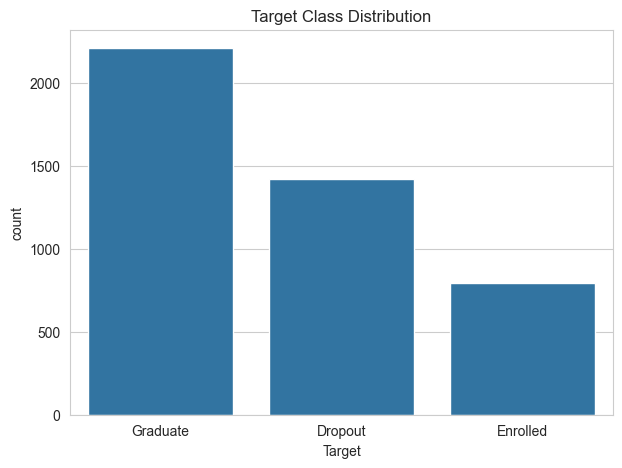

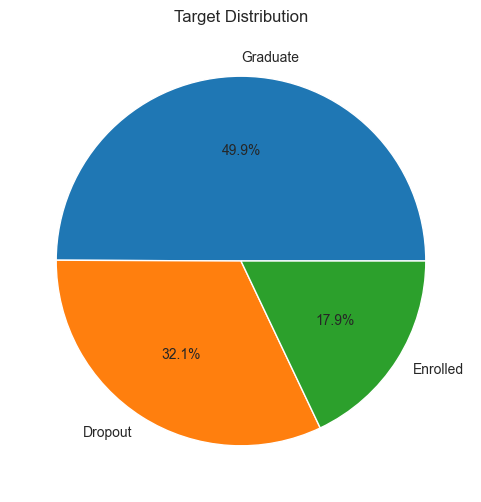

In [5]:
target_count = df["Target"].value_counts()

target_percent = round(
    df["Target"].value_counts(normalize=True)*100,
    2
)

summary = pd.DataFrame({
    "Count":target_count,
    "Percentage":target_percent
})

print(summary)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Target",
    order=target_count.index
)

plt.title("Target Class Distribution")
plt.show()

plt.figure(figsize=(6,6))

plt.pie(
    target_count,
    labels=target_count.index,
    autopct="%1.1f%%"
)

plt.title("Target Distribution")
plt.show()

### Step 6: Categorical Feature Analysis

Marital status
Marital status
1    3919
2     379
4      91
5      25
6       6
3       4
Name: count, dtype: int64


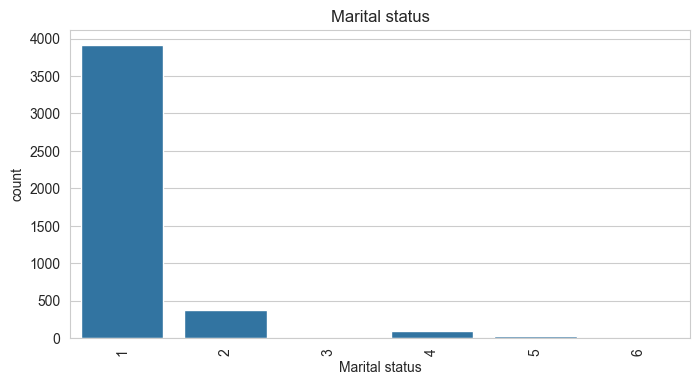

Application mode
Application mode
1     1708
17     872
39     785
43     312
44     213
7      139
18     124
42      77
51      59
16      38
53      35
15      30
5       16
10      10
2        3
57       1
26       1
27       1
Name: count, dtype: int64


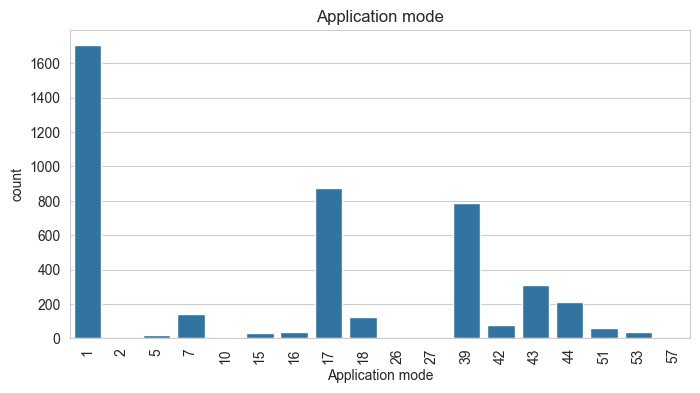

Application order
Application order
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
0       1
Name: count, dtype: int64


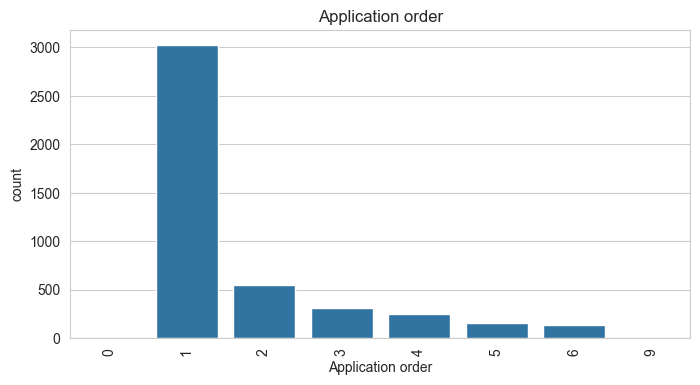

Course
Course
9500    766
9147    380
9238    355
9085    337
9773    331
9670    268
9991    268
9254    252
9070    226
171     215
8014    215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
Name: count, dtype: int64


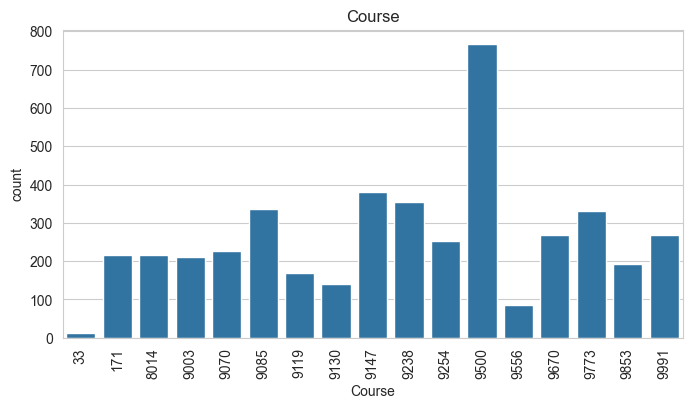

Daytime/evening attendance	
Daytime/evening attendance\t
1    3941
0     483
Name: count, dtype: int64


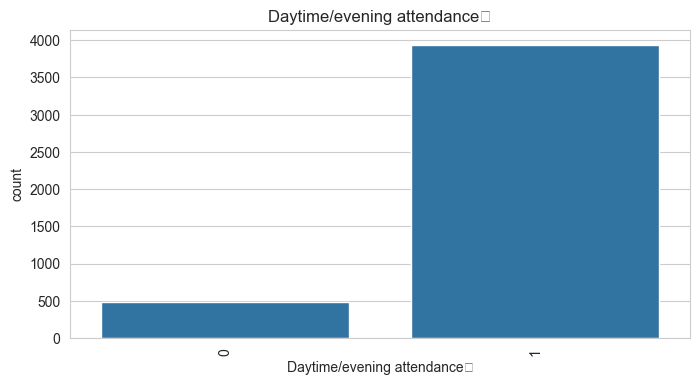

Previous qualification
Previous qualification
1     3717
39     219
19     162
3      126
12      45
40      40
42      36
2       23
6       16
9       11
4        8
38       7
43       6
10       4
15       2
5        1
14       1
Name: count, dtype: int64


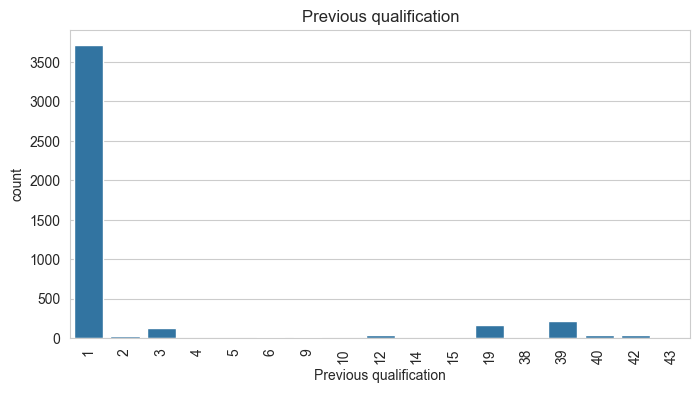

Nacionality
Nacionality
1      4314
41       38
26       14
6        13
22       13
24        5
100       3
11        3
103       3
62        2
21        2
101       2
25        2
2         2
105       2
32        1
13        1
109       1
108       1
14        1
17        1
Name: count, dtype: int64


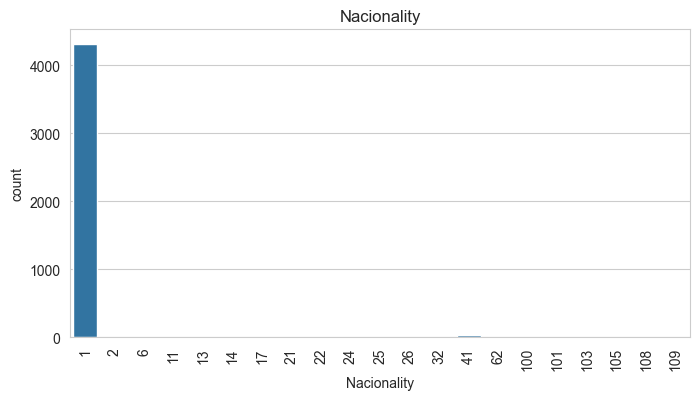

Mother's qualification
Mother's qualification
1     1069
37    1009
19     953
38     562
3      438
34     130
2       83
4       49
12      42
5       21
40       9
9        8
39       8
41       6
42       4
6        4
43       4
30       3
35       3
36       3
11       3
29       3
10       3
14       2
18       1
22       1
27       1
26       1
44       1
Name: count, dtype: int64


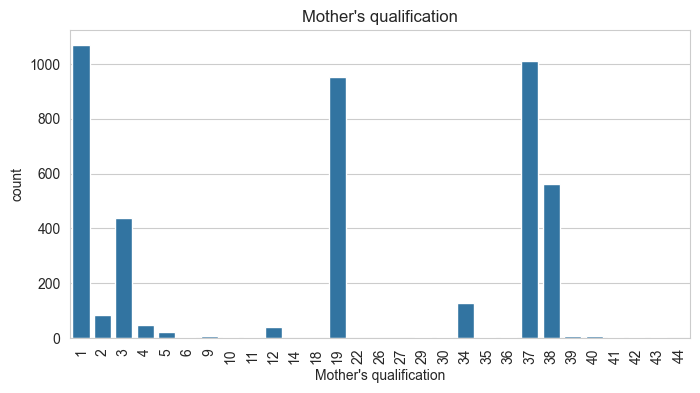

Father's qualification
Father's qualification
37    1209
19     968
1      904
38     702
3      282
34     112
2       68
4       39
12      38
39      20
5       18
11      10
36       8
9        5
40       5
14       4
30       4
22       4
29       3
26       2
43       2
41       2
10       2
6        2
35       2
20       1
42       1
18       1
13       1
25       1
44       1
33       1
27       1
31       1
Name: count, dtype: int64


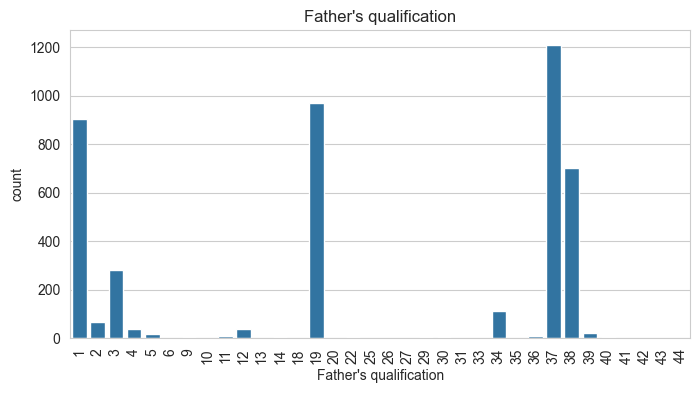

Mother's occupation
Mother's occupation
9      1577
4       817
5       530
3       351
2       318
7       272
0       144
1       102
6        91
90       70
8        36
191      26
99       17
194      11
141       8
123       7
144       6
175       5
192       5
10        4
134       4
193       4
151       3
132       3
143       3
153       2
152       2
122       2
125       1
173       1
131       1
171       1
Name: count, dtype: int64


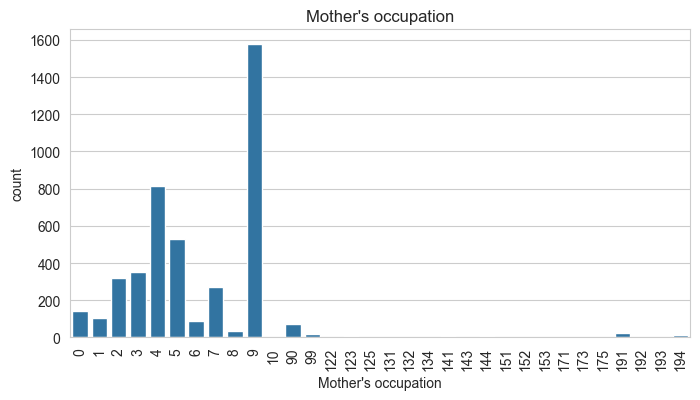

Father's occupation
Father's occupation
9      1010
7       666
5       516
4       386
3       384
8       318
10      266
6       242
2       197
1       134
0       128
90       65
99       19
193      15
144       8
171       8
192       6
163       5
103       4
175       4
181       3
135       3
152       3
183       3
123       3
112       2
194       2
182       2
172       2
151       2
102       2
122       2
124       1
131       1
195       1
121       1
132       1
161       1
143       1
134       1
153       1
174       1
141       1
114       1
101       1
154       1
Name: count, dtype: int64


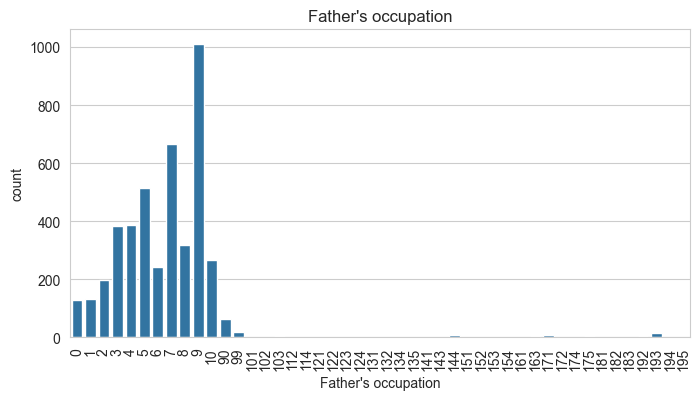

Displaced
Displaced
1    2426
0    1998
Name: count, dtype: int64


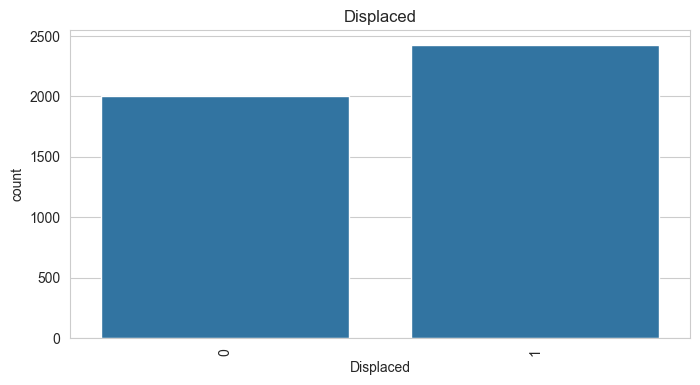

Educational special needs
Educational special needs
0    4373
1      51
Name: count, dtype: int64


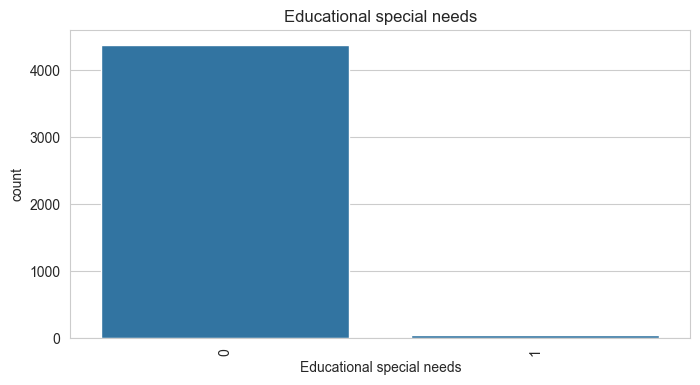

Debtor
Debtor
0    3921
1     503
Name: count, dtype: int64


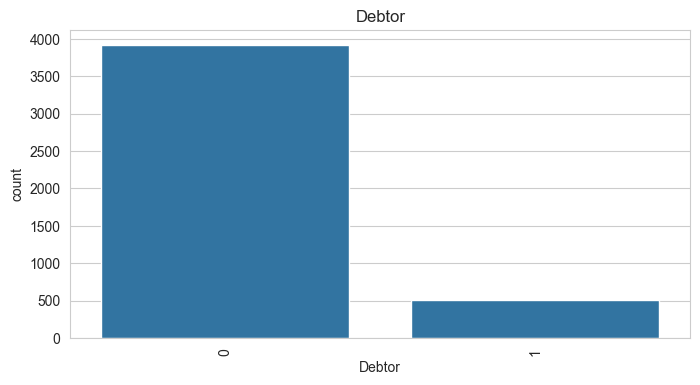

Tuition fees up to date
Tuition fees up to date
1    3896
0     528
Name: count, dtype: int64


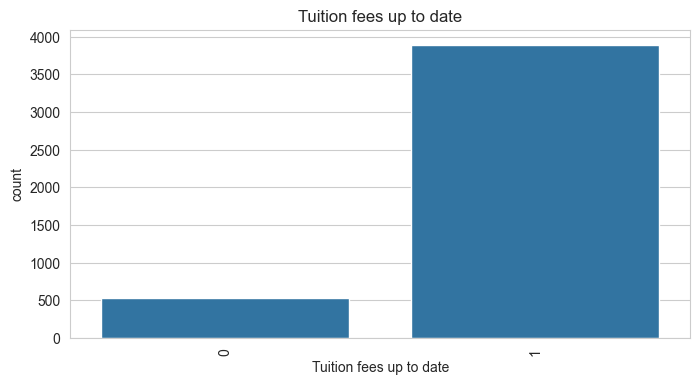

Gender
Gender
0    2868
1    1556
Name: count, dtype: int64


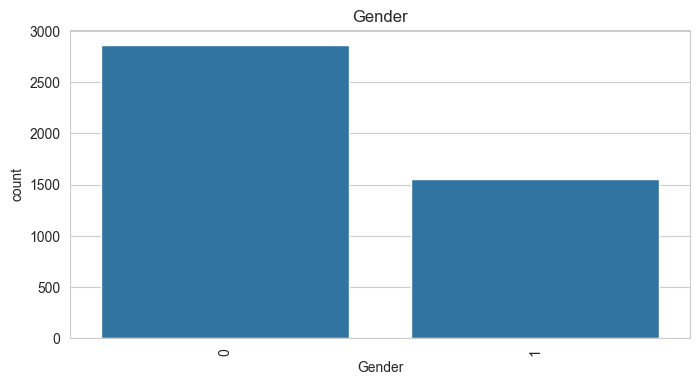

Scholarship holder
Scholarship holder
0    3325
1    1099
Name: count, dtype: int64


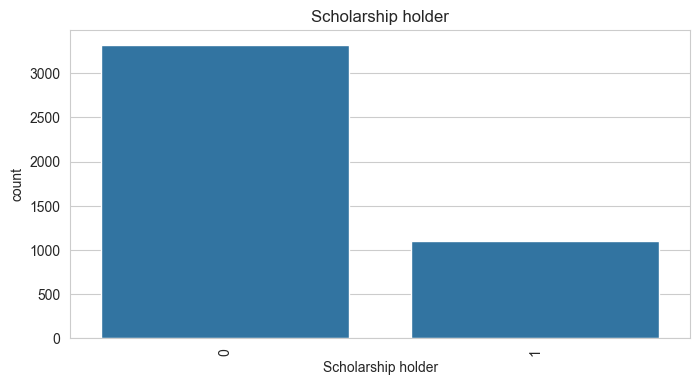

International
International
0    4314
1     110
Name: count, dtype: int64


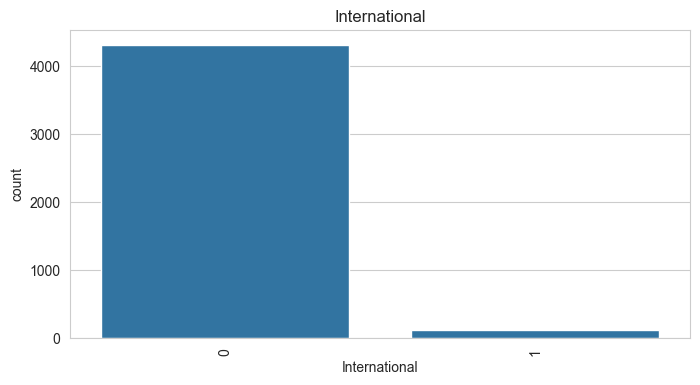

In [6]:
for col in categorical_columns[:-1]:

    print("="*60)
    print(col)
    print("="*60)

    print(df[col].value_counts())

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col
    )

    plt.xticks(rotation=90)
    plt.title(col)

    plt.show()

### Step 7: Categorical Features vs Target

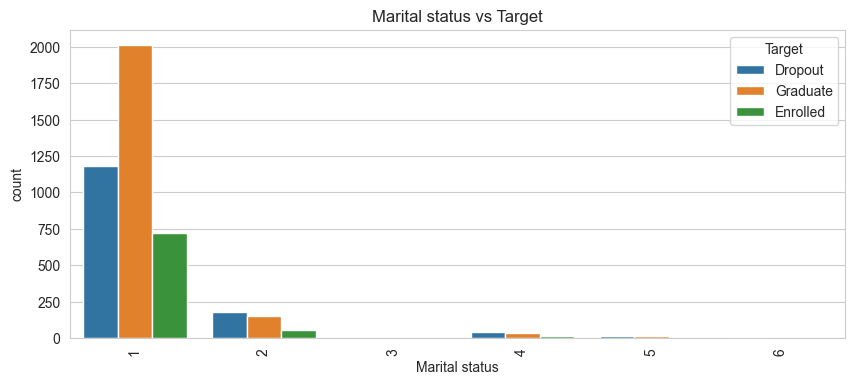

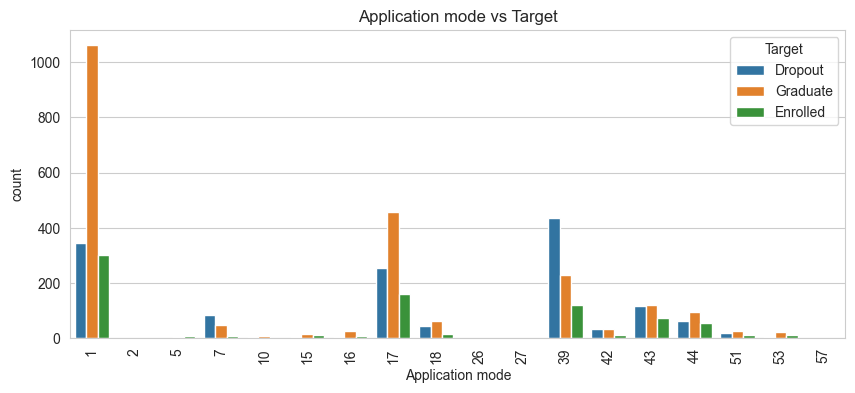

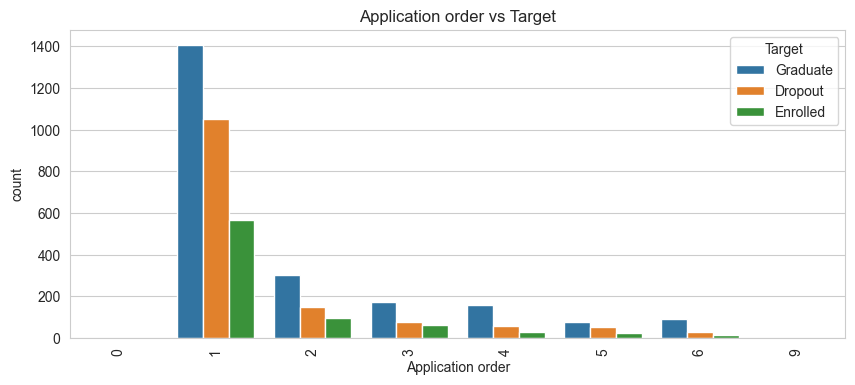

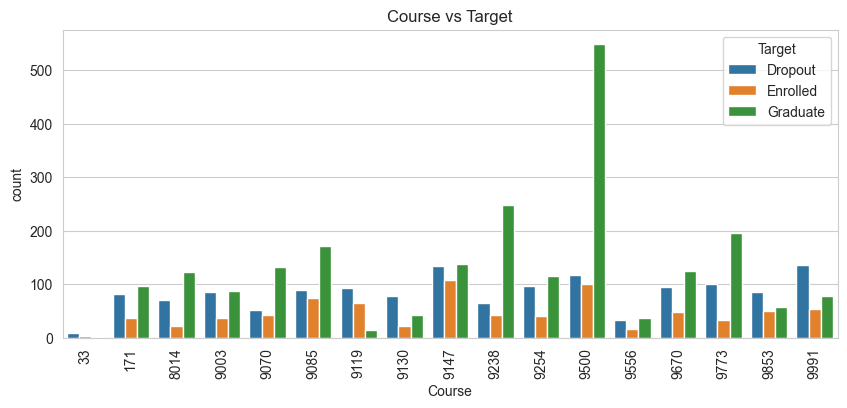

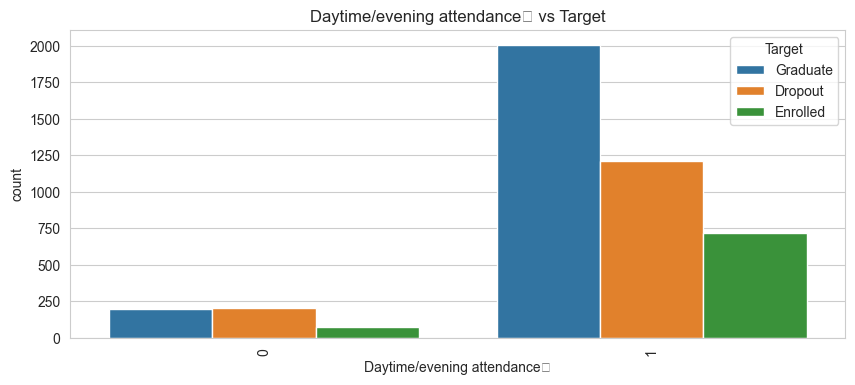

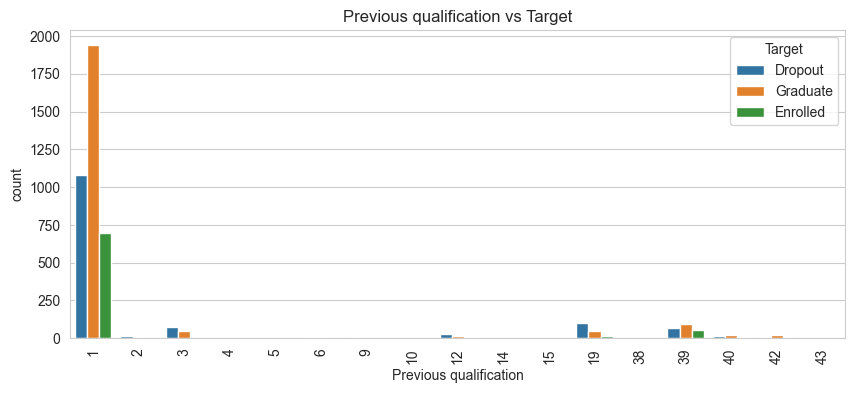

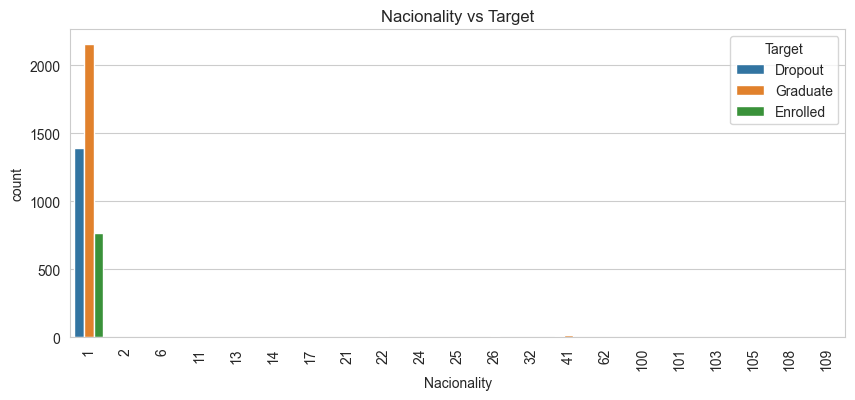

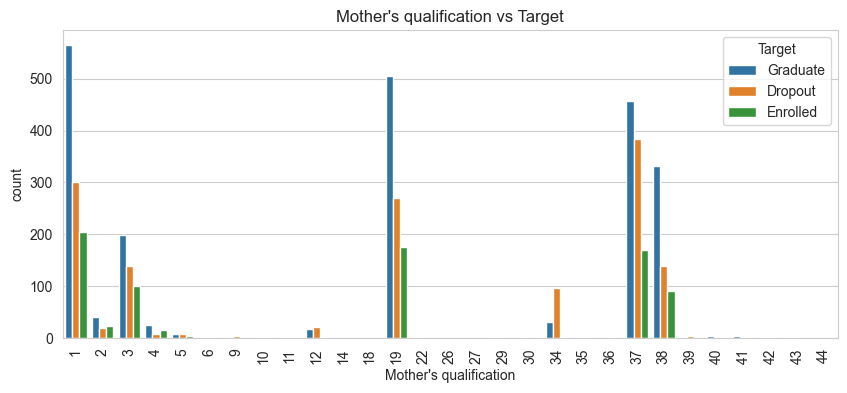

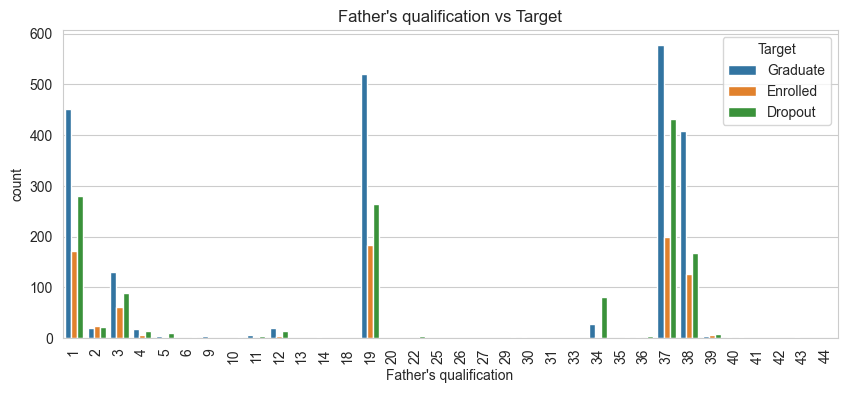

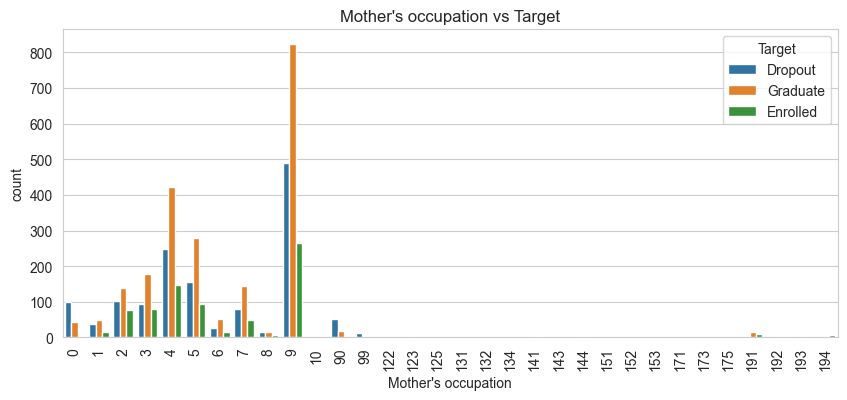

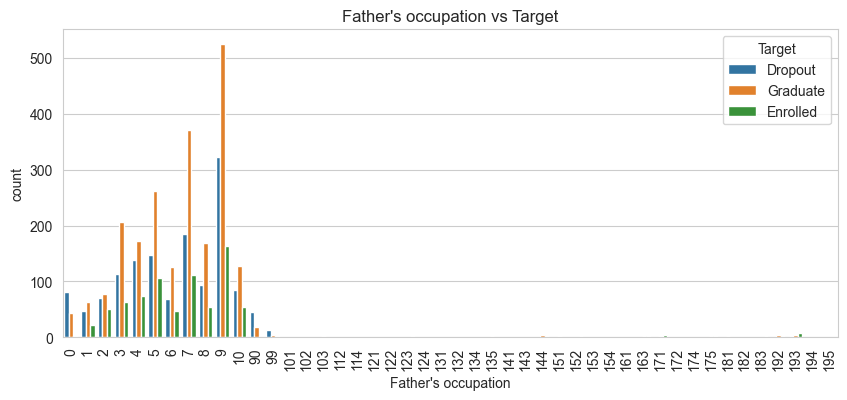

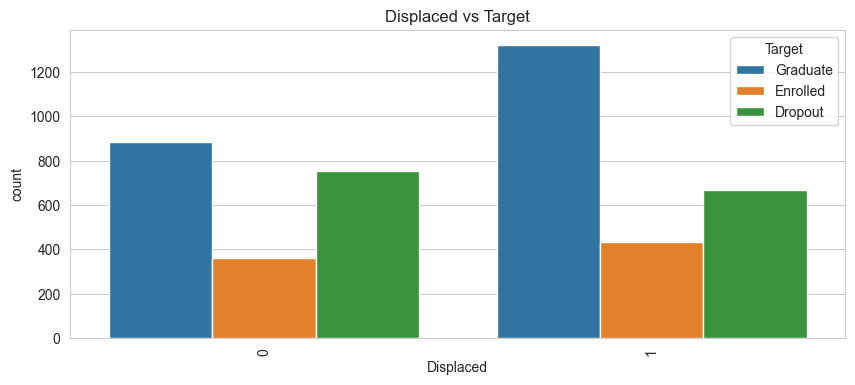

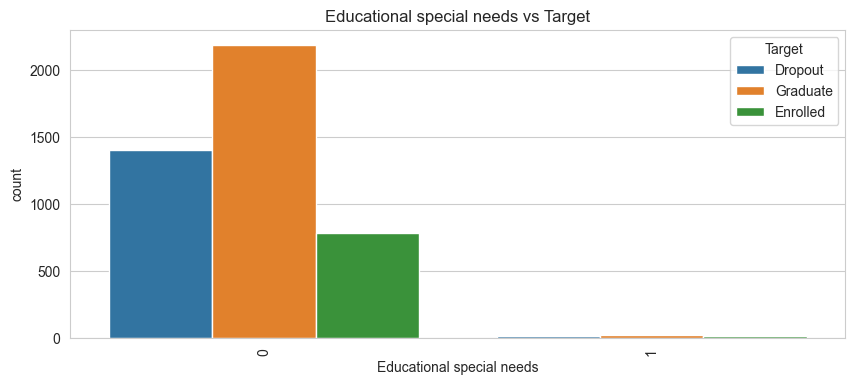

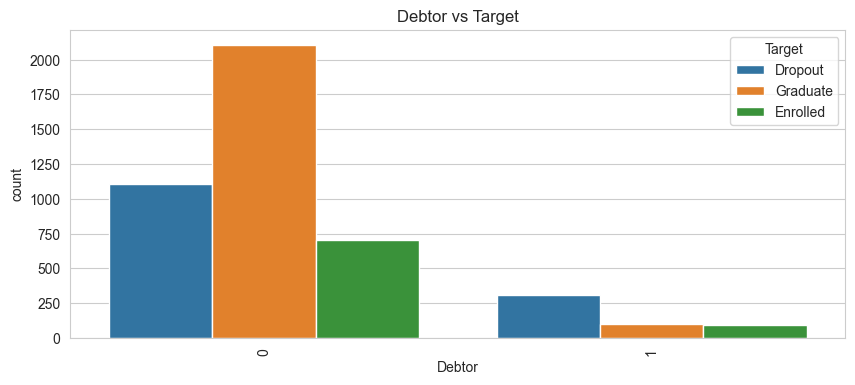

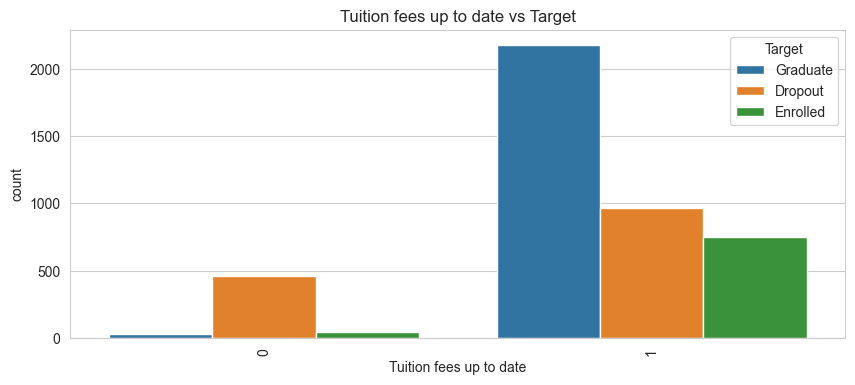

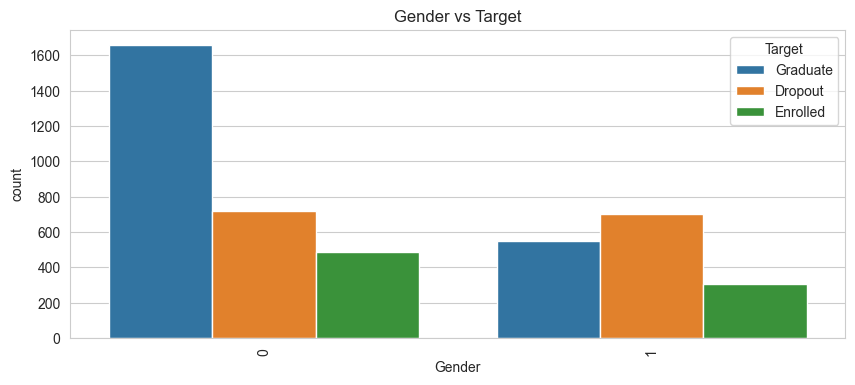

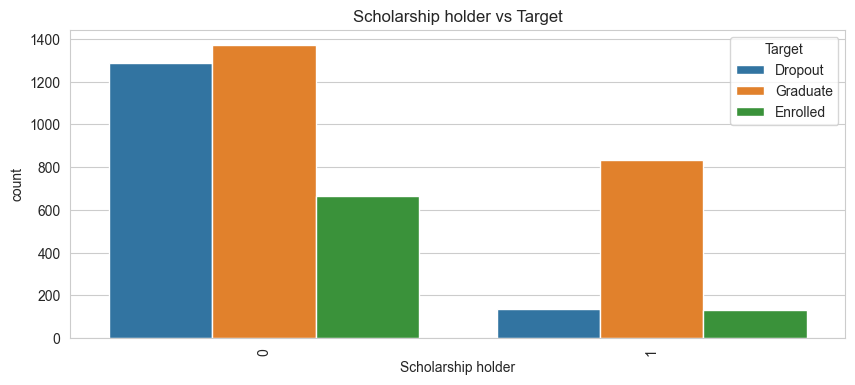

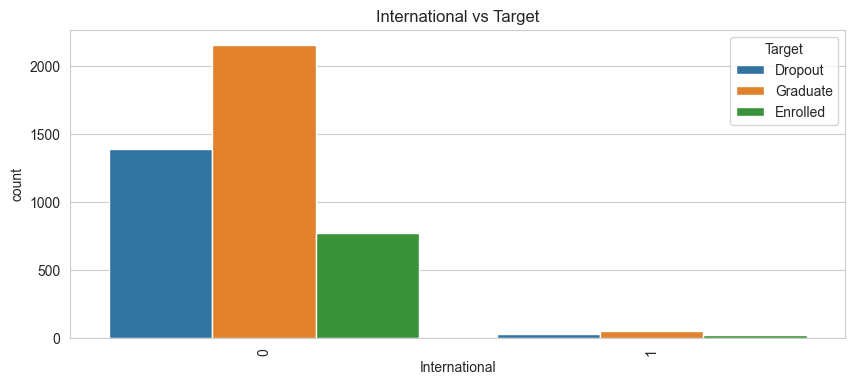

In [7]:
for col in categorical_columns[:-1]:

    plt.figure(figsize=(10,4))

    sns.countplot(
        data=df,
        x=col,
        hue="Target"
    )

    plt.xticks(rotation=90)

    plt.title(col + " vs Target")

    plt.show()

### Step 8: Numerical Feature Analysis

                                                 count        mean        std  \
Previous qualification (grade)                  4424.0  132.613314  13.188332   
Admission grade                                 4424.0  126.978119  14.482001   
Age at enrollment                               4424.0   23.265145   7.587816   
Curricular units 1st sem (credited)             4424.0    0.709991   2.360507   
Curricular units 1st sem (enrolled)             4424.0    6.270570   2.480178   
Curricular units 1st sem (evaluations)          4424.0    8.299051   4.179106   
Curricular units 1st sem (approved)             4424.0    4.706600   3.094238   
Curricular units 1st sem (grade)                4424.0   10.640822   4.843663   
Curricular units 1st sem (without evaluations)  4424.0    0.137658   0.690880   
Curricular units 2nd sem (credited)             4424.0    0.541817   1.918546   
Curricular units 2nd sem (enrolled)             4424.0    6.232143   2.195951   
Curricular units 2nd sem (ev

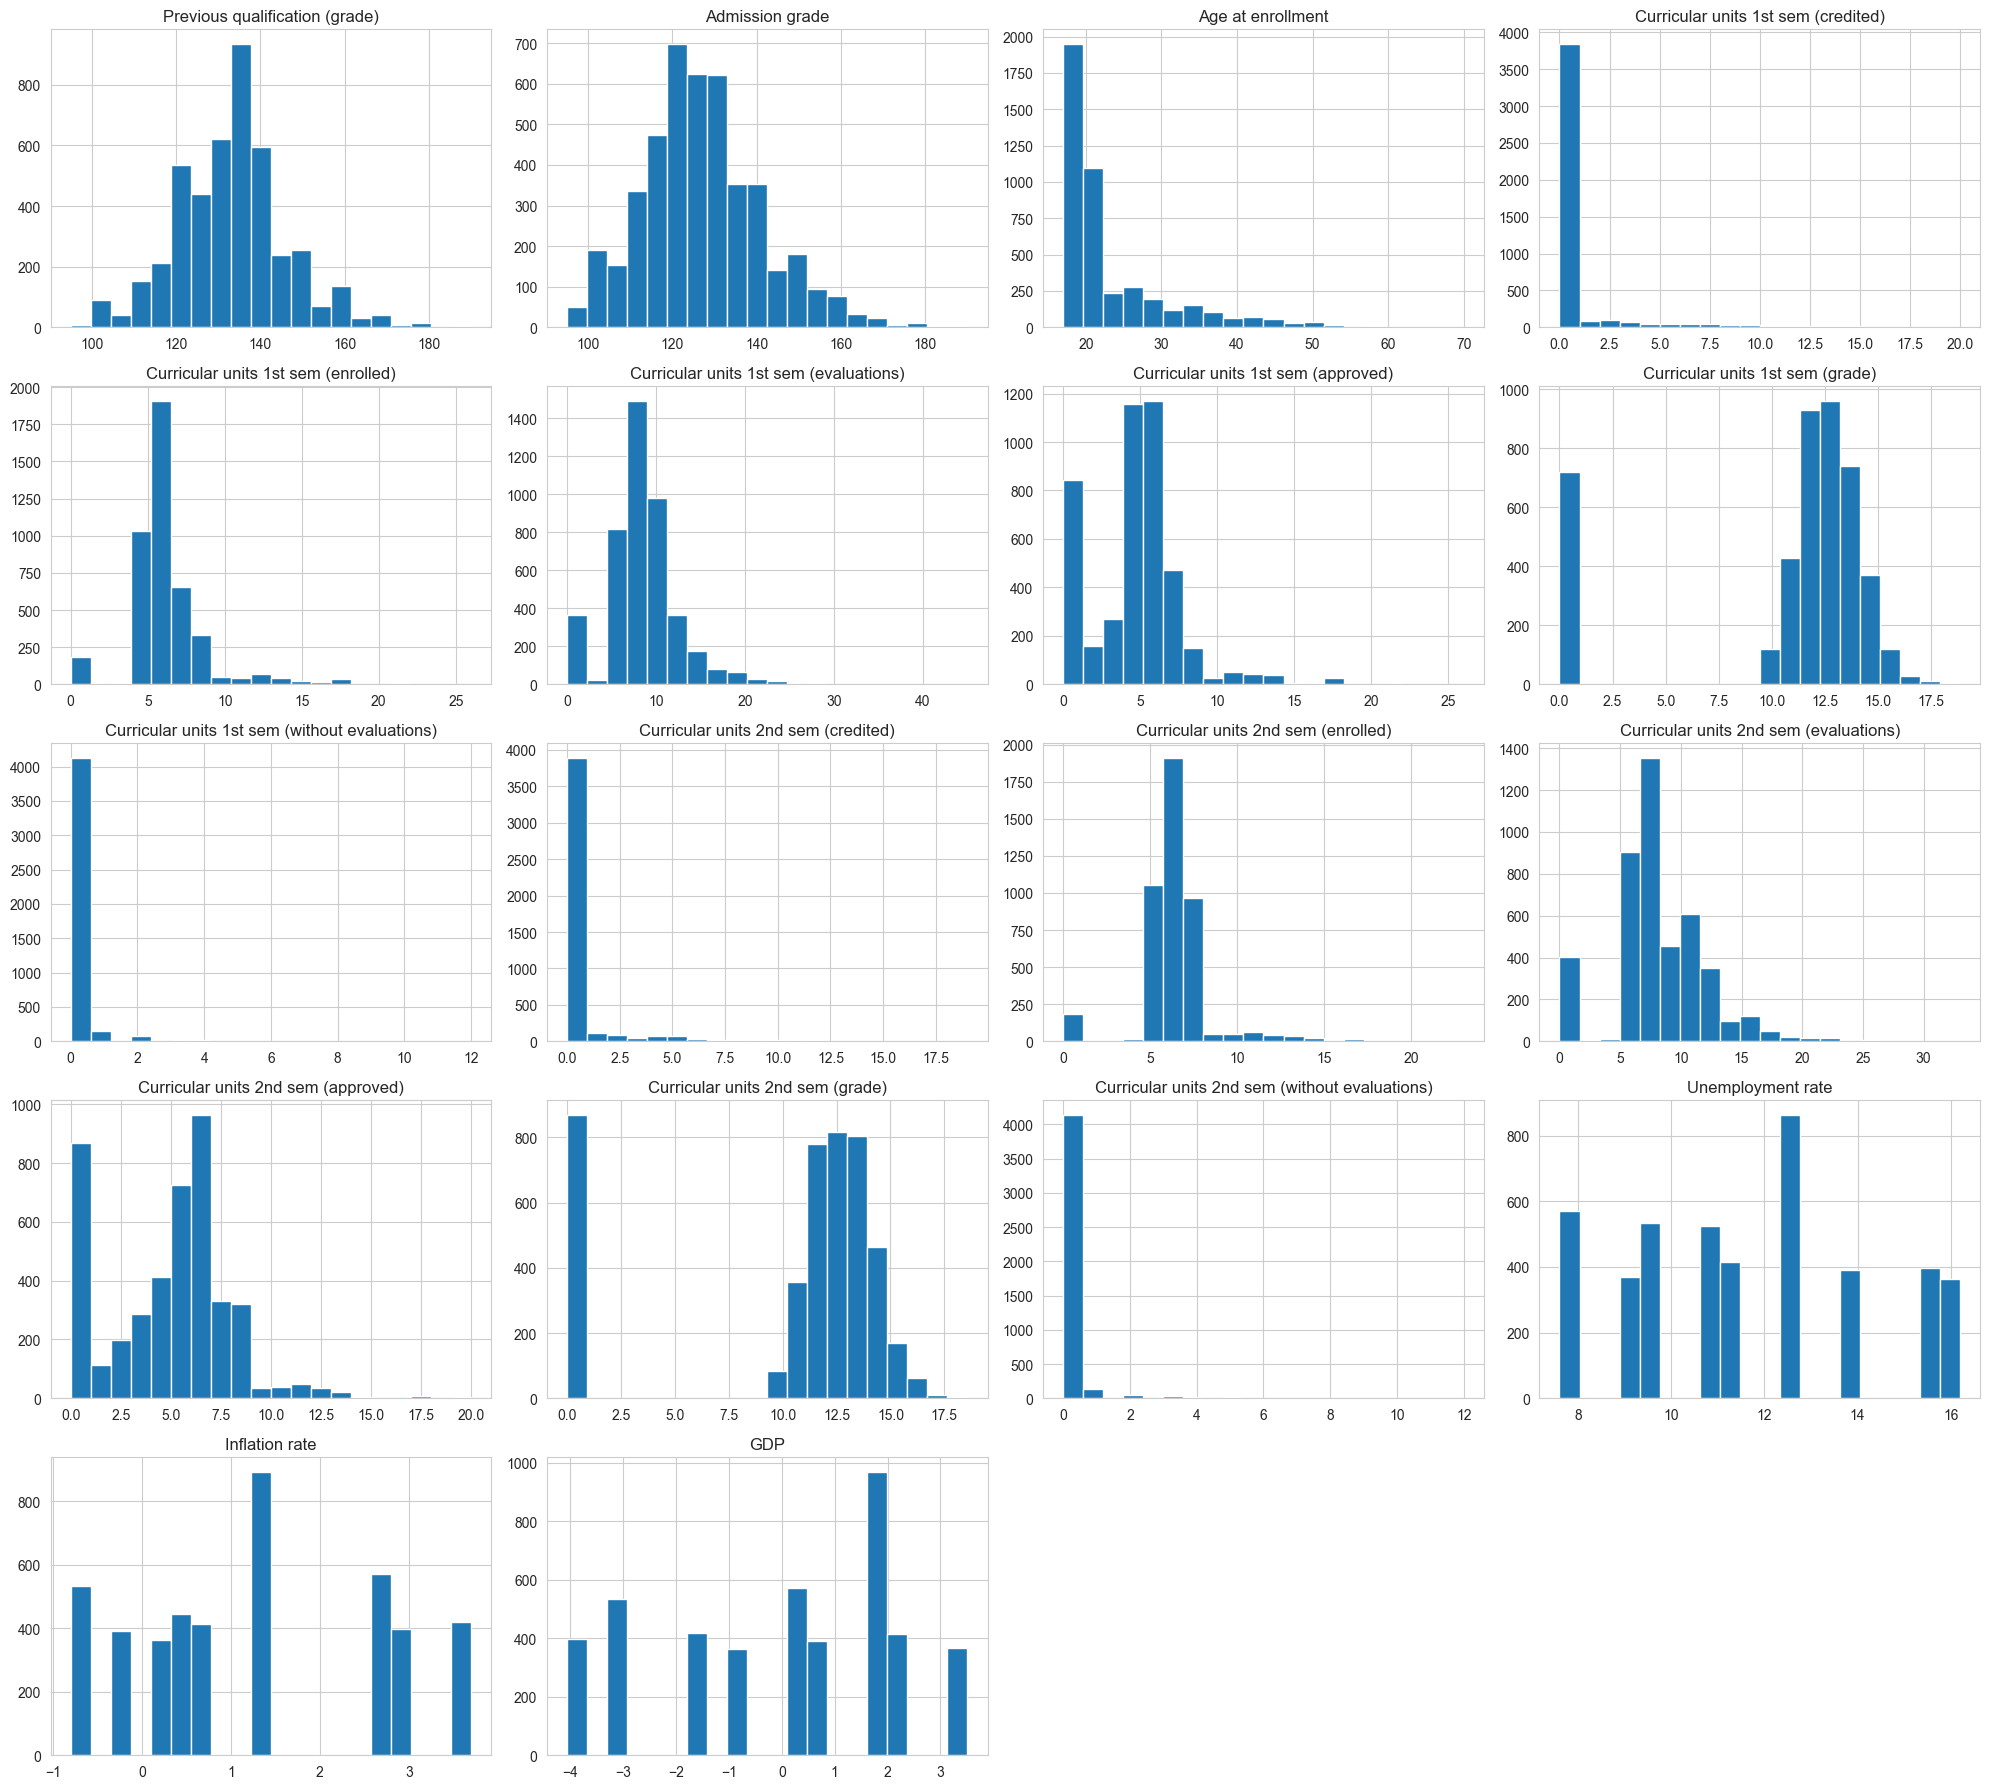

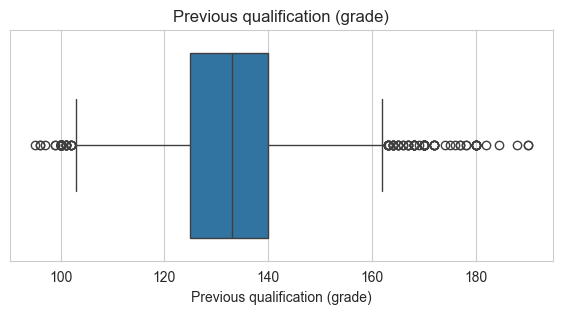

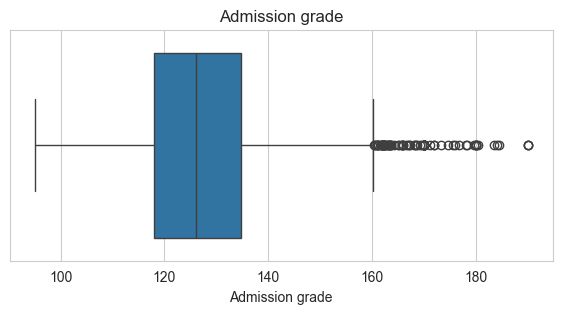

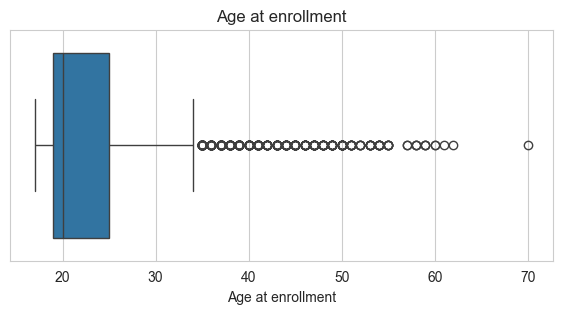

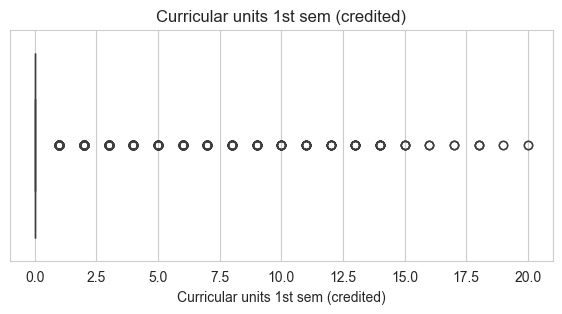

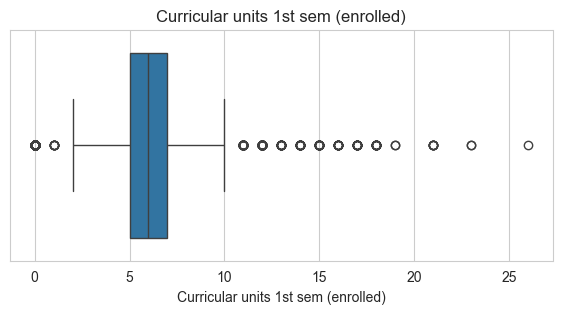

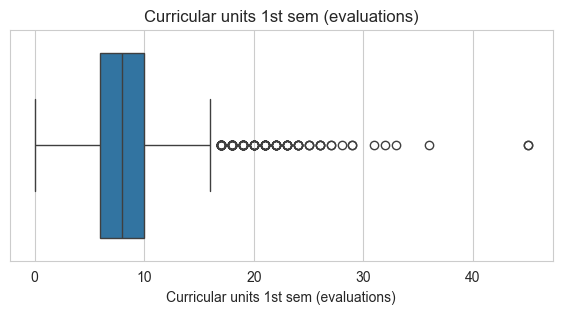

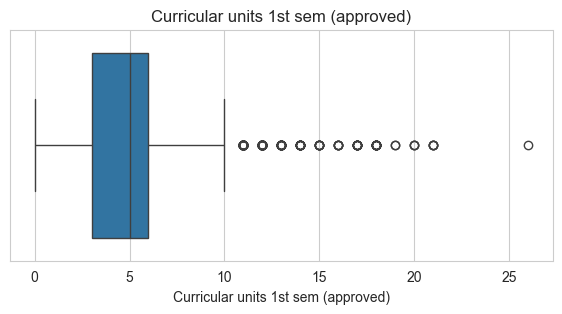

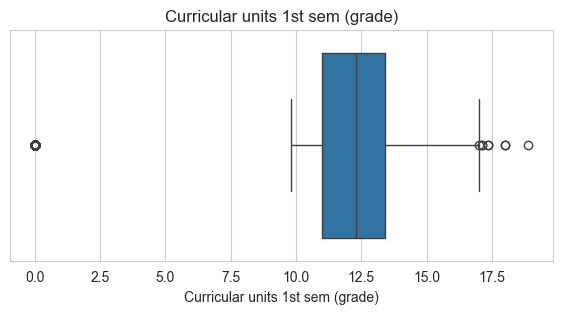

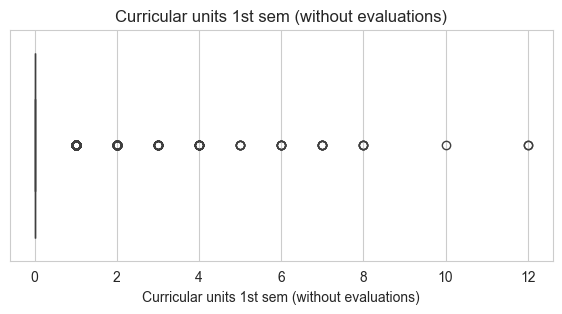

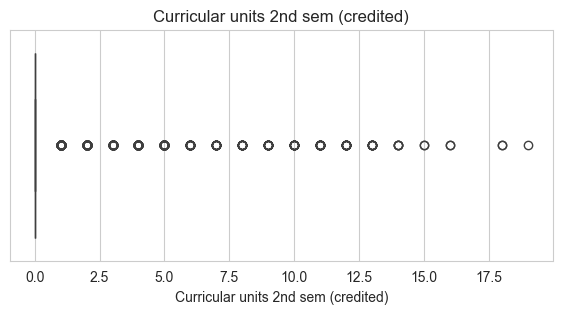

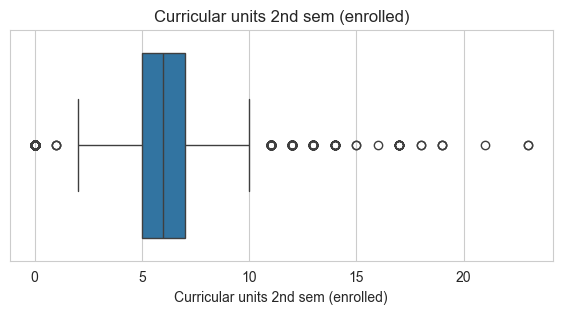

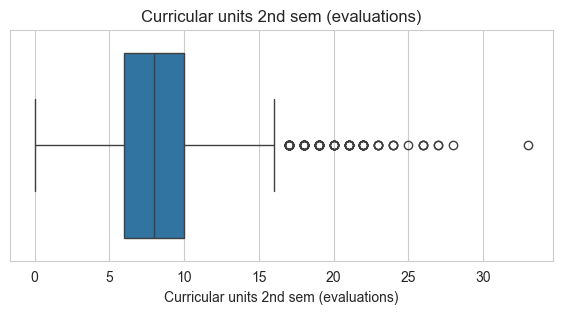

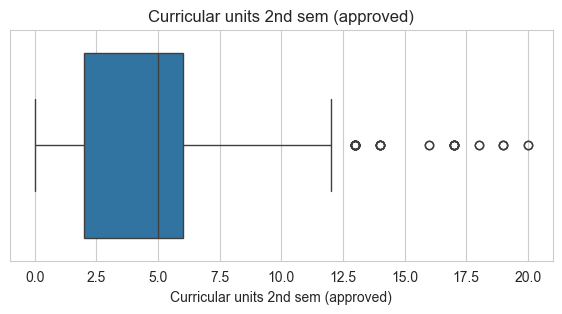

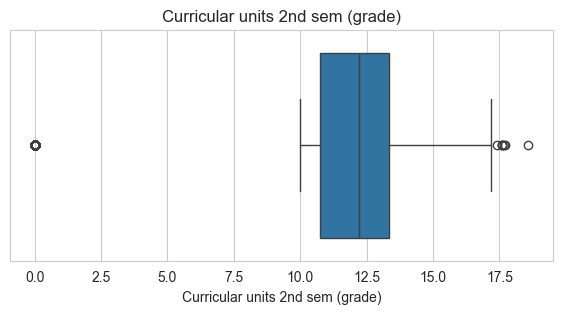

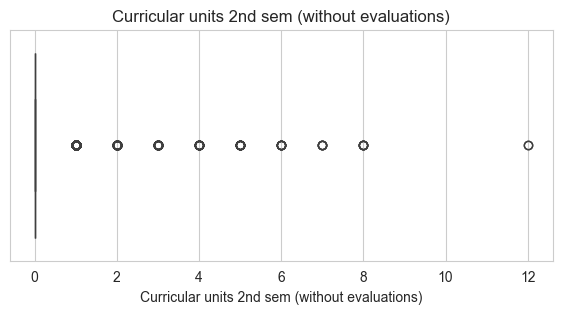

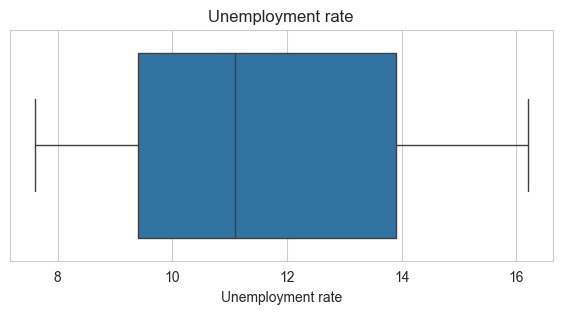

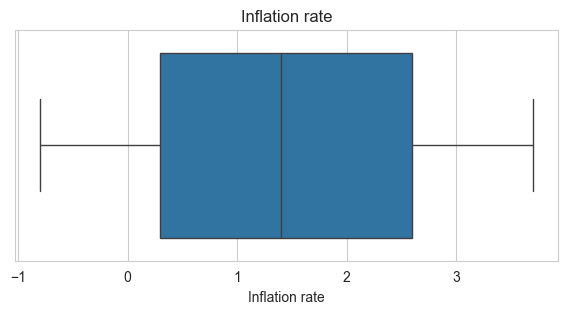

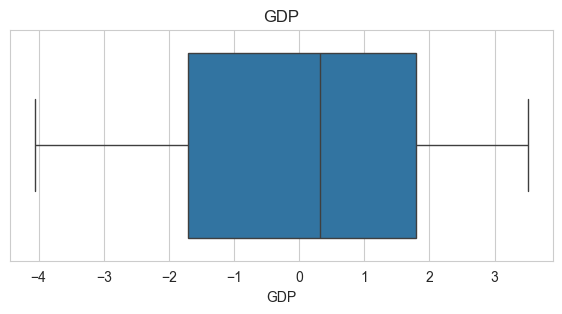

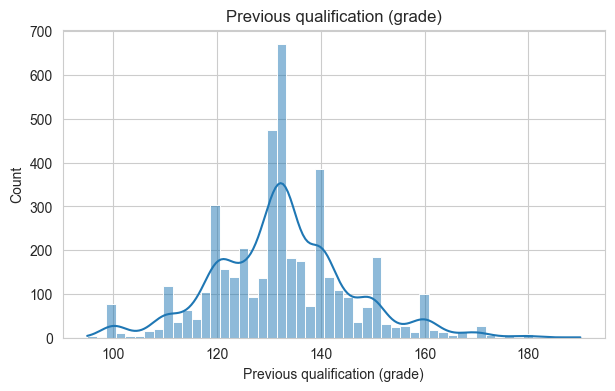

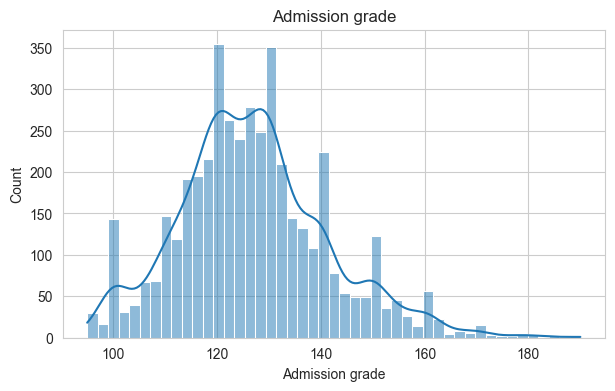

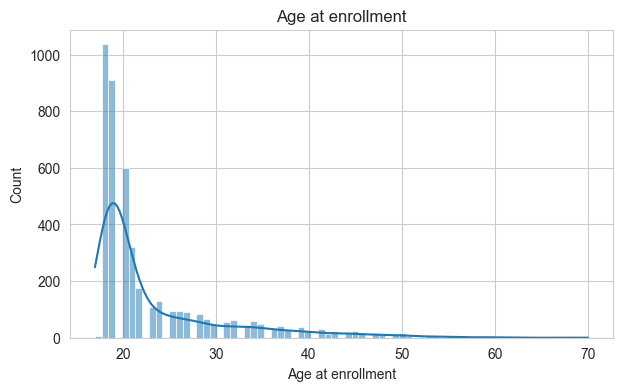

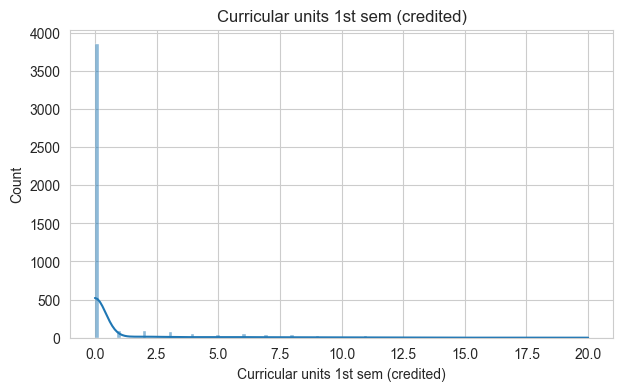

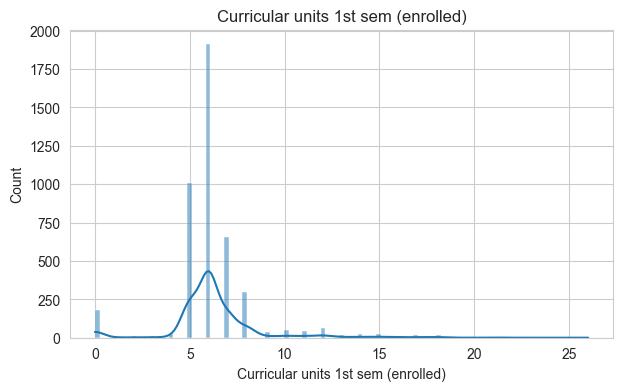

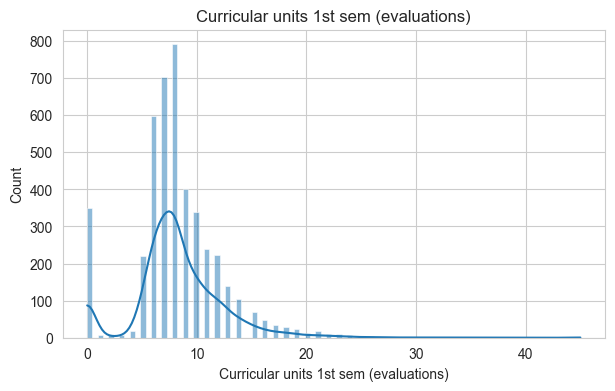

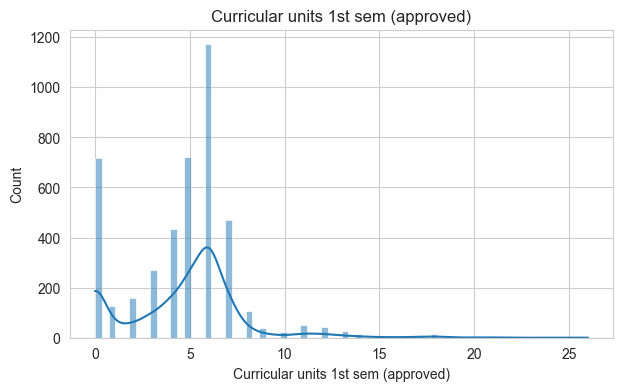

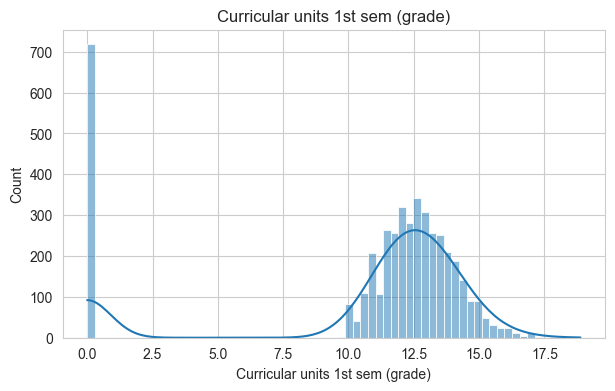

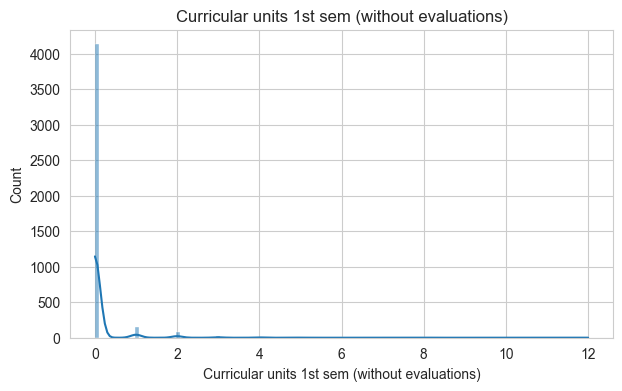

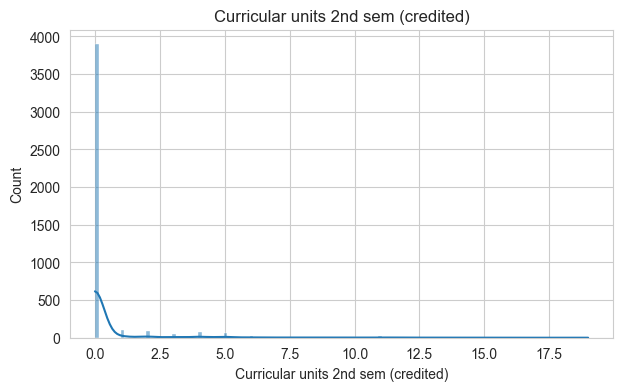

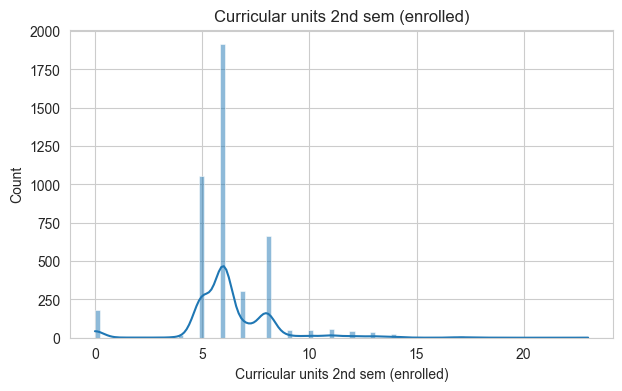

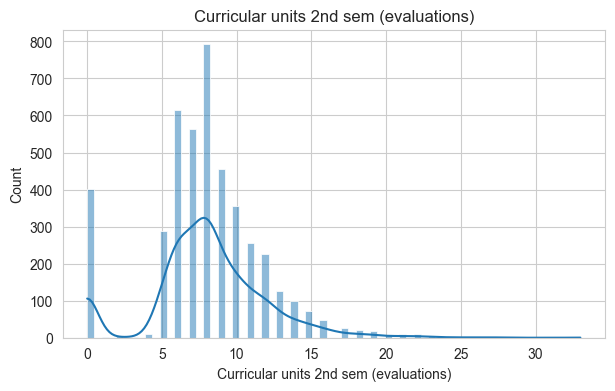

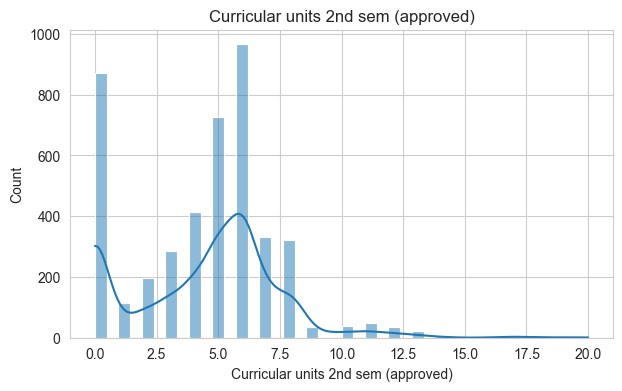

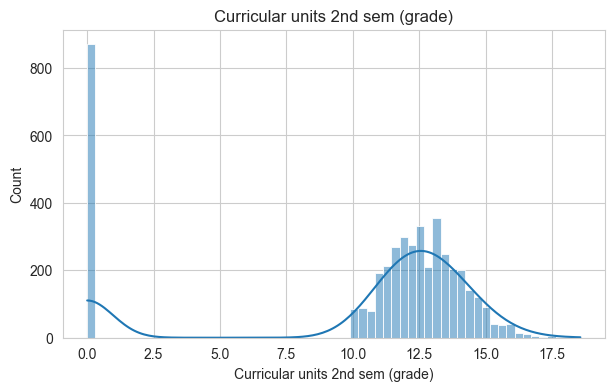

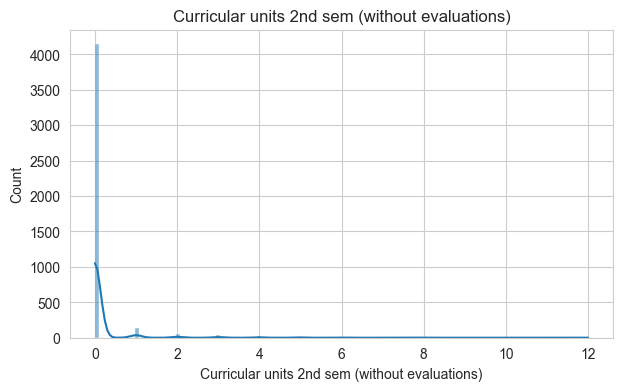

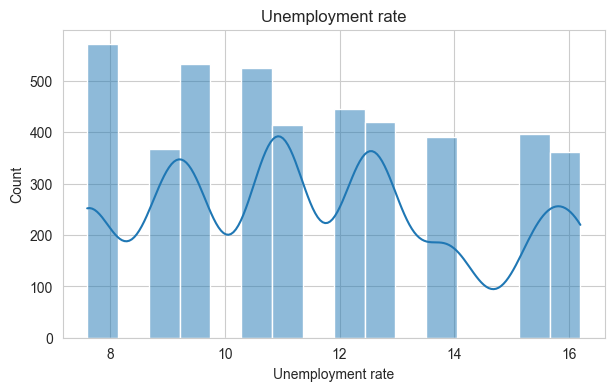

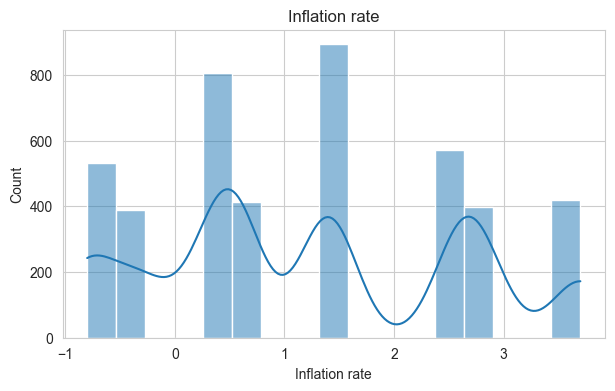

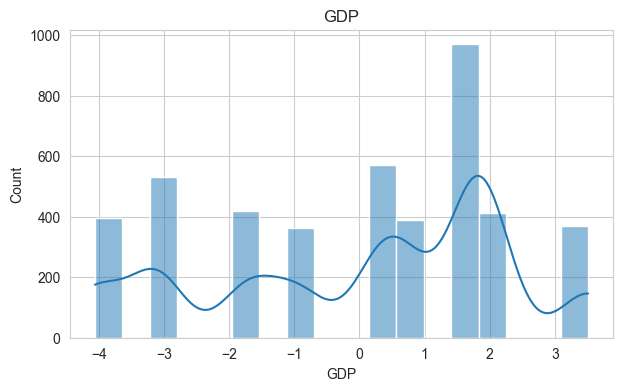

In [8]:
print(df[numerical_columns].describe().T)

df[numerical_columns].hist(
    figsize=(20,18),
    bins=20
)

plt.tight_layout()

plt.show()

for col in numerical_columns:

    plt.figure(figsize=(7,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

### Step 9: Correlation Analysis

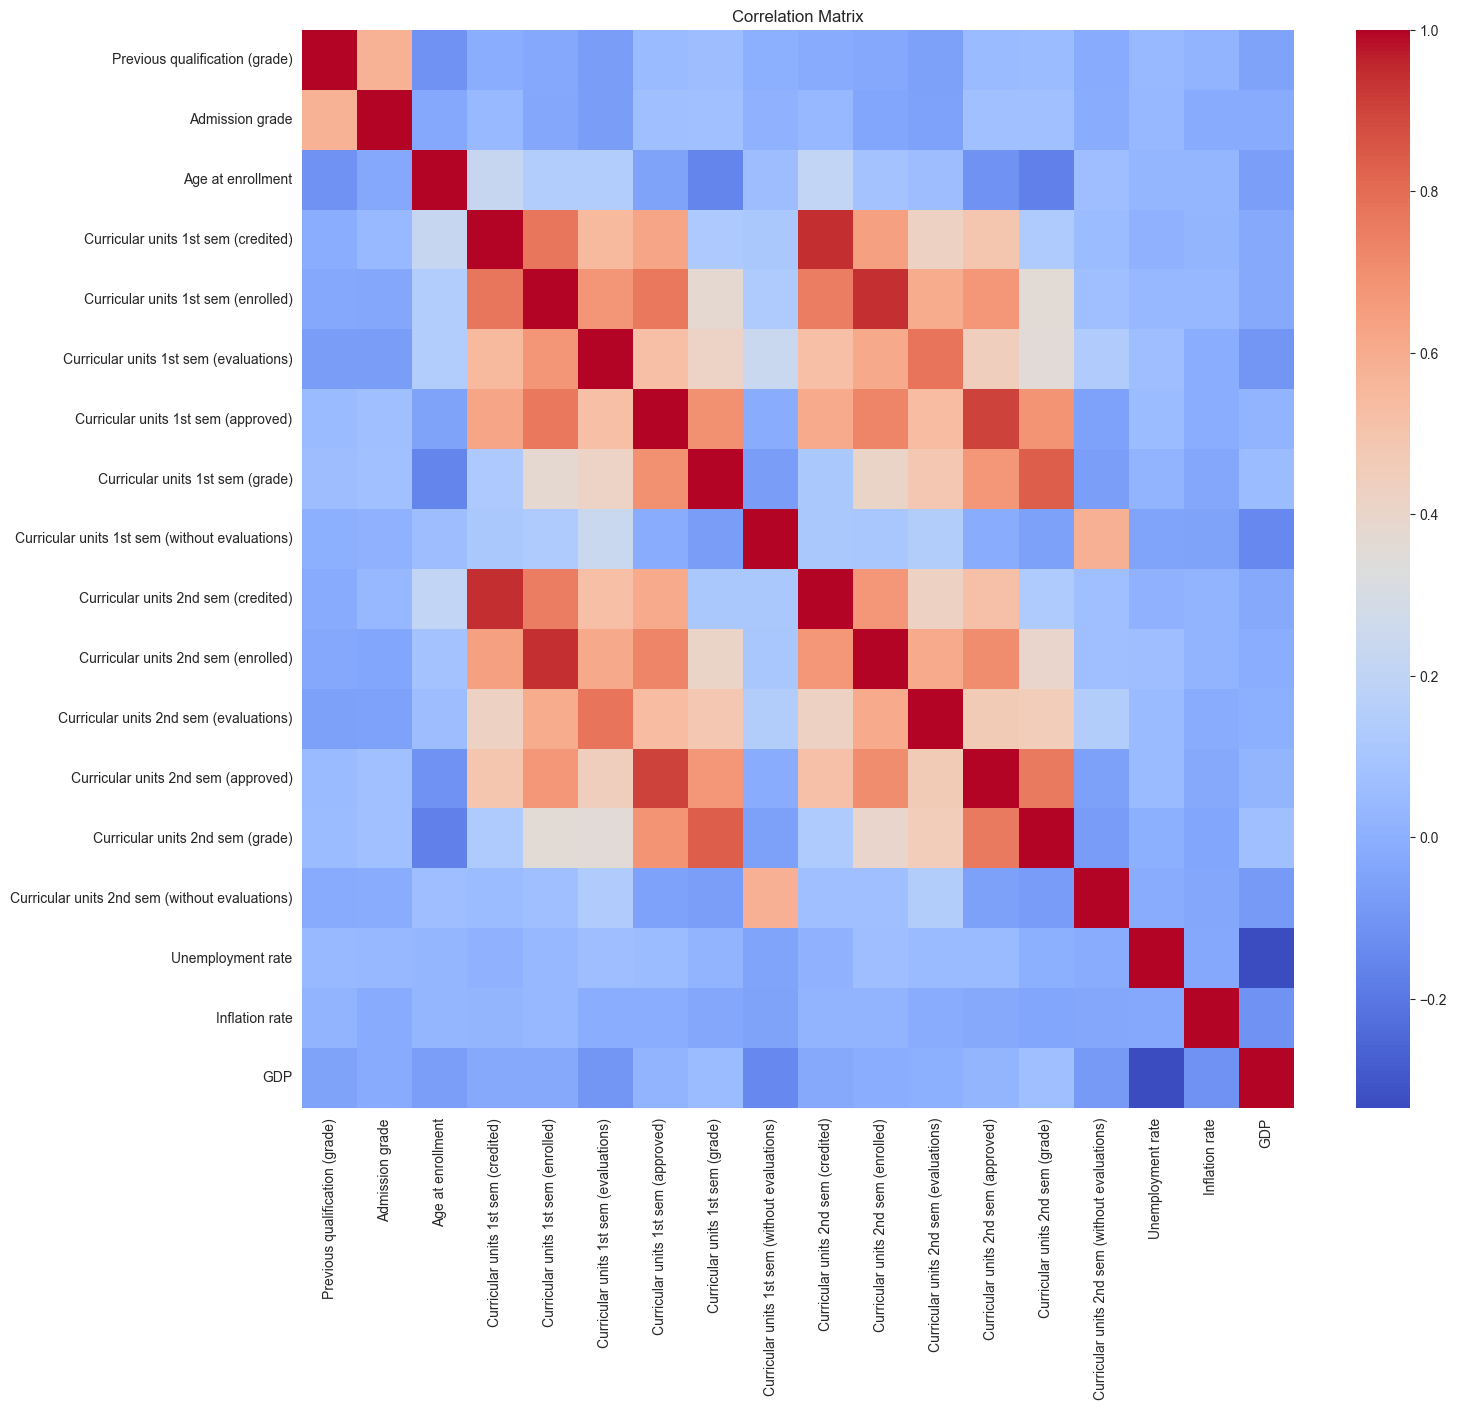

Highly Correlated Features (>0.80):
['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']


In [9]:
corr = df[numerical_columns].corr()

plt.figure(figsize=(16,14))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

upper = corr.abs().where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.80)
]

print("Highly Correlated Features (>0.80):")

print(high_corr)

### Step 10: Outlier Analysis

                                           Feature  Number of Outliers
13                Curricular units 2nd sem (grade)                 877
7                 Curricular units 1st sem (grade)                 726
3              Curricular units 1st sem (credited)                 577
9              Curricular units 2nd sem (credited)                 530
2                                Age at enrollment                 441
4              Curricular units 1st sem (enrolled)                 424
10             Curricular units 2nd sem (enrolled)                 369
8   Curricular units 1st sem (without evaluations)                 294
14  Curricular units 2nd sem (without evaluations)                 282
6              Curricular units 1st sem (approved)                 180
0                   Previous qualification (grade)                 179
5           Curricular units 1st sem (evaluations)                 158
11          Curricular units 2nd sem (evaluations)                 109
1     

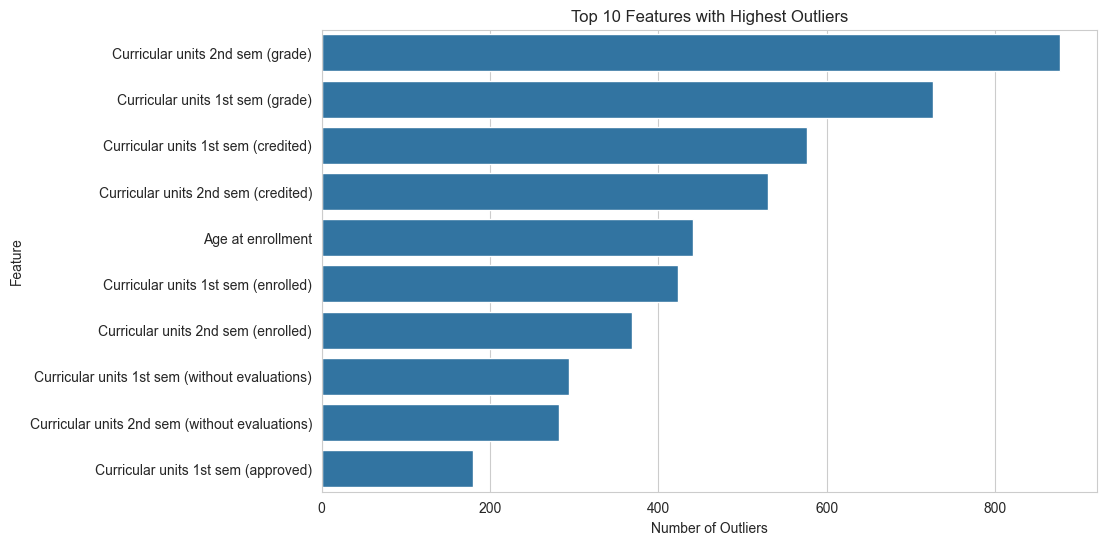

In [10]:
outliers = {}

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR

    upper = Q3+1.5*IQR

    outliers[col] = (
        (
            (df[col] < lower) |
            (df[col] > upper)
        ).sum()
    )

outlier_df = pd.DataFrame(
    outliers.items(),
    columns=["Feature","Number of Outliers"]
)

outlier_df = outlier_df.sort_values(
    by="Number of Outliers",
    ascending=False
)

print(outlier_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=outlier_df.head(10),
    x="Number of Outliers",
    y="Feature"
)

plt.title("Top 10 Features with Highest Outliers")

plt.show()

### Step 11: Distribution Characteristics

In [11]:
summary = pd.DataFrame({
    "Mean":df[numerical_columns].mean(),
    "Median":df[numerical_columns].median(),
    "Variance":df[numerical_columns].var(),
    "Skewness":df[numerical_columns].skew(),
    "Kurtosis":df[numerical_columns].kurt()
})

print(summary)

zero_variance = summary[
    summary["Variance"]==0
]

print("\nZero Variance Features")

print(zero_variance)

                                                      Mean      Median  \
Previous qualification (grade)                  132.613314  133.100000   
Admission grade                                 126.978119  126.100000   
Age at enrollment                                23.265145   20.000000   
Curricular units 1st sem (credited)               0.709991    0.000000   
Curricular units 1st sem (enrolled)               6.270570    6.000000   
Curricular units 1st sem (evaluations)            8.299051    8.000000   
Curricular units 1st sem (approved)               4.706600    5.000000   
Curricular units 1st sem (grade)                 10.640822   12.285714   
Curricular units 1st sem (without evaluations)    0.137658    0.000000   
Curricular units 2nd sem (credited)               0.541817    0.000000   
Curricular units 2nd sem (enrolled)               6.232143    6.000000   
Curricular units 2nd sem (evaluations)            8.063291    8.000000   
Curricular units 2nd sem (approved)   

### Step 12: EDA Summary

In [12]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print(f"\nNumerical Features : {len(numerical_columns)}")

print(f"Categorical Features : {len(categorical_columns)}")

print(f"\nMissing Values : {df.isnull().sum().sum()}")

print(f"Duplicate Rows : {df.duplicated().sum()}")

print(f"\nTarget Classes : {df['Target'].nunique()}")

print("\nTarget Distribution")

print(summary := pd.DataFrame({
    "Count":df["Target"].value_counts(),
    "Percentage":round(df["Target"].value_counts(normalize=True)*100,2)
}))

print("\nHighly Correlated Features (>0.80)")

print(high_corr)

print("\nTop 10 Features with Most Outliers")

print(outlier_df.head(10))

EDA SUMMARY
Dataset Shape : (4424, 37)

Numerical Features : 18
Categorical Features : 19

Missing Values : 0
Duplicate Rows : 0

Target Classes : 3

Target Distribution
          Count  Percentage
Target                     
Graduate   2209       49.93
Dropout    1421       32.12
Enrolled    794       17.95

Highly Correlated Features (>0.80)
['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']

Top 10 Features with Most Outliers
                                           Feature  Number of Outliers
13                Curricular units 2nd sem (grade)                 877
7                 Curricular units 1st sem (grade)                 726
3              Curricular units 1st sem (credited)                 577
9              Curricular units 2nd sem (credited)                 530
2                                Age at enrollment                 441
4              Curricular units 1st se